In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [3]:
df_final = pd.read_csv("./files/df_final.csv")
df_final.info()

<class 'pandas.DataFrame'>
RangeIndex: 403760 entries, 0 to 403759
Data columns (total 24 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   Unnamed: 0                   403760 non-null  int64  
 1   Loyalty Number               403760 non-null  int64  
 2   Year                         403760 non-null  int64  
 3   Month                        403760 non-null  int64  
 4   Flights Booked               403760 non-null  int64  
 5   Flights with Companions      403760 non-null  int64  
 6   Total Flights                403760 non-null  int64  
 7   Distance                     403760 non-null  int64  
 8   Points Accumulated           403760 non-null  float64
 9   Points Redeemed              403760 non-null  int64  
 10  Dollar Cost Points Redeemed  403760 non-null  int64  
 11  Country                      403760 non-null  str    
 12  Province                     403760 non-null  str    
 13  City      

# Fase 3: Visualización

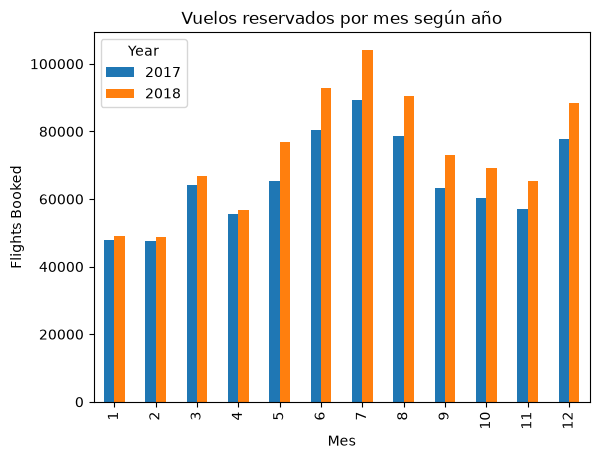

In [ ]:
# -. ¿Cómo se distribuye la cantidad de vuelos reservados por mes durante el año?

vuelos_mes = df_final.groupby(["Year","Month"])["Flights Booked"].sum().unstack()

vuelos_mes.T.plot(kind="bar")

plt.title("Vuelos reservados por mes según año")
plt.xlabel("Mes")
plt.ylabel("Flights Booked")

plt.show()

- El mes con mayor reserva de vuelos ha sido julio, para ambos años
- El mes con menor numero de reservas de vuelos para ambos años ha sido enero
- Podemos observar que ambos años siguen patrones muy parecidos
- A modo curiosidad quiero destacar el mes de diciembre como mes donde tambien se genera un gran
numero de vuelos, dadas las fiestas.

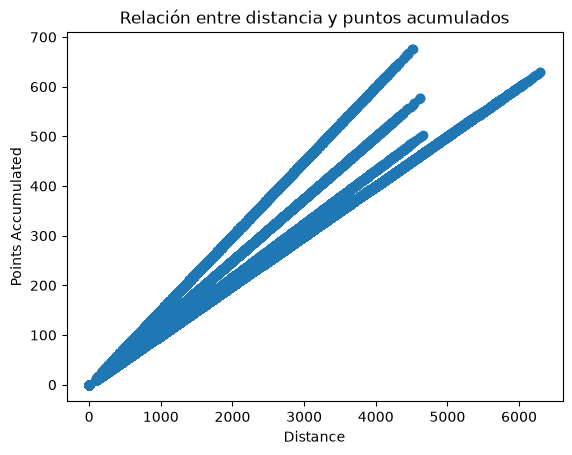

In [ ]:
# /. ¿Existe una relación entre la distancia de los vuelos y los puntos acumulados por los cliente?
plt.scatter(
    df_final["Distance"],
    df_final["Points Accumulated"]
)

plt.title("Relación entre distancia y puntos acumulados")
plt.xlabel("Distance")
plt.ylabel("Points Accumulated")

plt.show()

- Podemos ver que a mayor distancia recorrida, mayor cantidad de puntos acumuladosm esto cumple con una logica de negocio donde las aerolineas compensan a sus clientes con vuelos mas largos

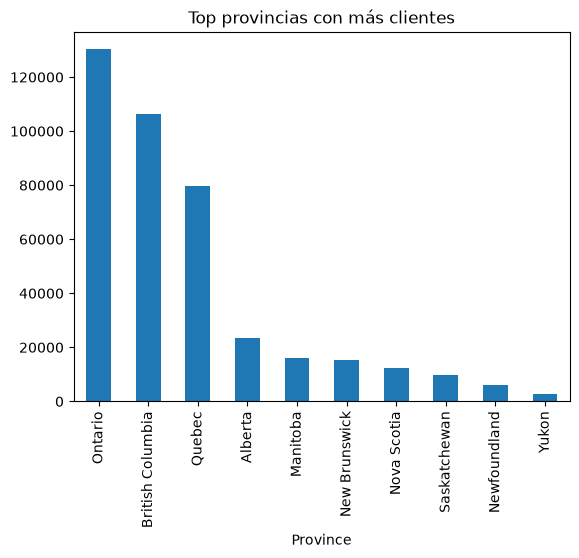

In [ ]:
# ¿Cuál es la distribución de los clientes por provincia o estado?
df_final["Province"].value_counts().head(10).plot(kind="bar")

plt.title("Top provincias con más clientes")
plt.show()

- Vemos que la provincia mas dominante es Ontario

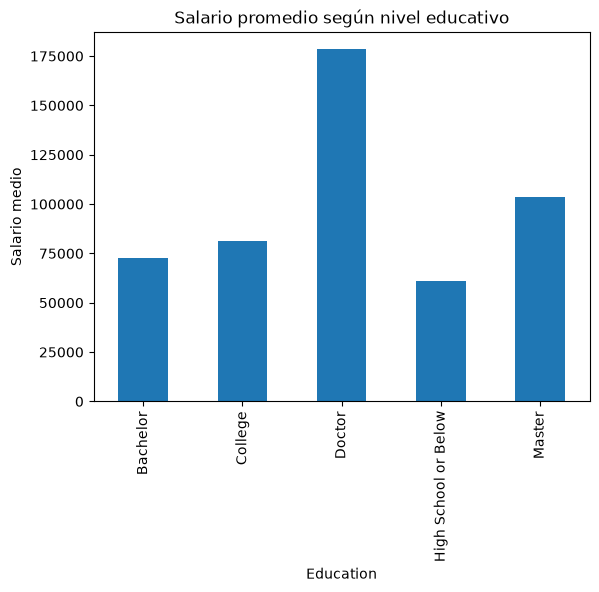

In [ ]:
# ¿Cómo se compara el salario promedio entre los diferentes niveles educativos de los clientes?
df_final.groupby("Education")["Salary"].mean().plot(kind="bar")

plt.title("Salario promedio según nivel educativo")
plt.ylabel("Salario medio")

plt.show()

- Los clientes con mayor formación académica presentan, en promedio, ingresos significativamente superiores.

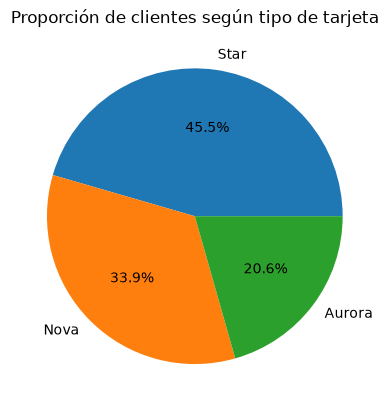

In [ ]:
# ¿Cuál es la proporción de clientes con diferentes tipos de tarjetas de fidelidad?
df_final["Loyalty Card"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.title("Proporción de clientes según tipo de tarjeta")

plt.ylabel("")

plt.show()

- Se observa una concentración importante de clientes en la categoría Star, lo que sugiere que este nivel de fidelización es el más accesible o el más utilizado dentro de la estrategia comercial de la aerolínea.

In [10]:
estado_genero = pd.crosstab(
    df_final["Marital Status"],
    df_final["Gender"]
)

print(estado_genero)

Gender          Female    Male
Marital Status                
Divorced         30634   30128
Married         117363  117482
Single           54760   53393


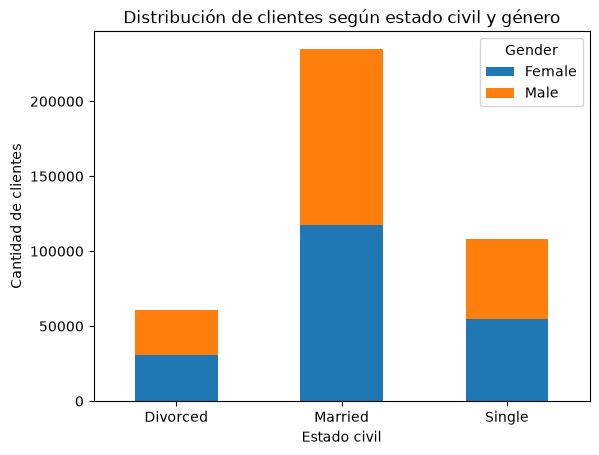

In [ ]:
#¿Cómo se distribuyen los clientes según su estado civil y género?
estado_genero = pd.crosstab(
    df_final["Marital Status"],
    df_final["Gender"]
)

estado_genero.plot(
    kind="bar",
    stacked=True
)

plt.title("Distribución de clientes según estado civil y género")
plt.xlabel("Estado civil")
plt.ylabel("Cantidad de clientes")
plt.xticks(rotation=0)

plt.show()

- La mayor parte de clientes pertenecen al grupo de personas casadas, representando claramente la categoría dominante dentro de la base de clientes.
- La base de clientes presenta una distribución prácticamente equilibrada entre hombres y mujeres,
lo mismo ocurre con single y Divorced